In [2]:
import matplotlib.pyplot as plt
import numpy as np
from math import log
%matplotlib inline


# Functions

In [3]:
def Gaussian_loglikelihood(X, mu, sigma):
    n = len(X)
    return (
        -n / 2 * log(2 * np.pi)
        - n / 2 * log(sigma**2)
        - 1 / (2 * sigma**2) * sum([(x - mu) ** 2 for x in X])
    )


def MLE(X, sigma):
    l = []
    maxll = -9999999
    bestmu = -9999999
    mus = np.arange(-100, 100, 0.01)
    for mu in mus:
        ll = Gaussian_loglikelihood(X, mu, sigma)
        l.append(ll)
        if ll > maxll:
            bestmu = mu
            maxll = ll
    return bestmu, mus, l




# Maximum Log Likelihood

6.540000000054505
[-100.    -99.99  -99.98 ...   99.97   99.98   99.99]
[-4310320.7228721455, -4309894.564000376, -4309468.445128609, -4309042.366256837, -4308616.327385066, -4308190.328513283, -4307764.369641505, -4307338.450769732, -4306912.571897948, -4306486.733026179, -4306060.934154406, -4305635.1752826115, -4305209.456410844, -4304783.777539064, -4304358.138667302, -4303932.53979552, -4303506.980923764, -4303081.462051969, -4302655.983180198, -4302230.544308421, -4301805.14543665, -4301379.786564871, -4300954.467693098, -4300529.188821329, -4300103.949949575, -4299678.751077742, -4299253.592205984, -4298828.473334203, -4298403.394462435, -4297978.35559066, -4297553.356718862, -4297128.397847114, -4296703.478975315, -4296278.600103555, -4295853.761231781, -4295428.962360001, -4295004.2034882195, -4294579.484616453, -4294154.805744674, -4293730.166872913, -4293305.568001118, -4292881.009129348, -4292456.490257564, -4292032.011385813, -4291607.572513998, -4291183.173642237, -429075

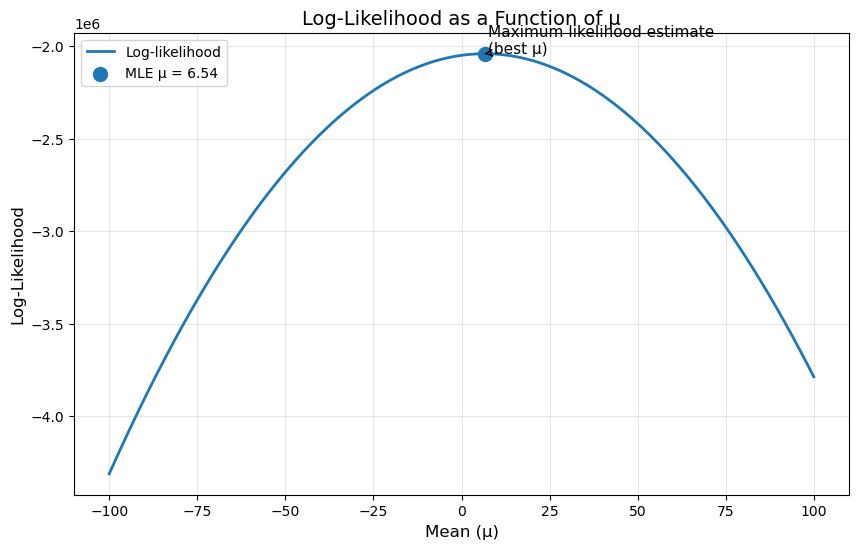

In [13]:
mu_true = 7 
sigma_true = 100
X = np.random.normal(
    mu_true, sigma_true, 1000
)  # generate 1000 samples from this gaussian


bestmu, mus, l = MLE(X, sigma=5)
print(bestmu)
print(mus)
print(l)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(mus, l, linewidth=2, label="Log-likelihood")
plt.scatter(bestmu, max(l), s=100, zorder=3, label=f"MLE μ = {bestmu:.2f}")
plt.title("Log-Likelihood as a Function of μ", fontsize=14)
plt.xlabel("Mean (μ)", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.annotate(
    "Maximum likelihood estimate\n(best μ)",
    xy=(bestmu, max(l)),
    xytext=(bestmu + 1, max(l) - 2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.show()

# Bayesian model


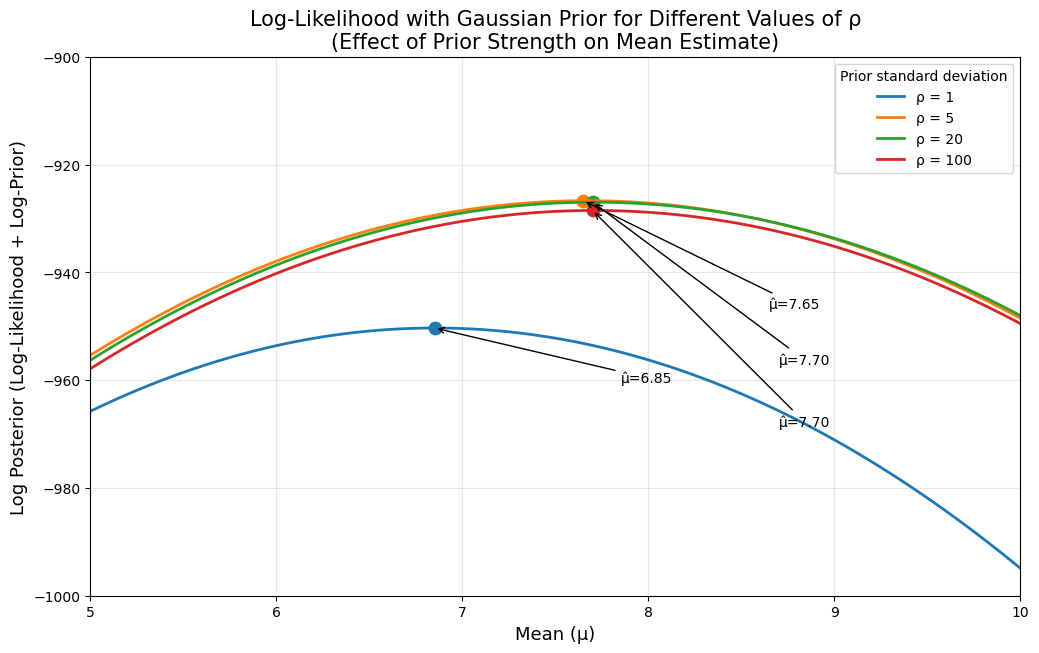

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from math import log

########## ---------- Variables ---------- ##########
alpha = 0
rho_values = [1, 5, 20, 100]

########## ---------- Functions ---------- ##########
# Log-likelihood with Gaussian prior
def Gaussian_loglikelihood(X, mu, sigma, alpha, rho):
    n = len(X)
    return (
        -n / 2 * log(2 * np.pi)
        - n / 2 * log(sigma**2)
        - 1 / (2 * sigma**2) * sum((x - mu) ** 2 for x in X)
        - log(2 * np.pi) / 2
        - log(rho**2) / 2
        - (alpha - mu)**2 / (2 * rho**2)
    )

def MLE(X, sigma, alpha, rho):
    l = []
    maxll = -1e20
    bestmu = None
    mus = np.arange(-50, 50, 0.05)

    for mu in mus:
        ll = Gaussian_loglikelihood(X, mu, sigma, alpha, rho)
        l.append(ll)
        if ll > maxll:
            maxll = ll
            bestmu = mu

    return bestmu, mus, l

########## ---------- Generate synthetic data ---------- ##########
np.random.seed(0)
mu_true = 7
sigma_true = 10
X = np.random.normal(mu_true, sigma_true, 200)

########## ---------- PLOT ---------- ##########
plt.figure(figsize=(12, 7))

i = 0
for rho in rho_values:
    i += 1

    bestmu, mus, l = MLE(X, sigma=5, alpha=alpha, rho=rho)

    plt.plot(mus, l, linewidth=2, label=f"ρ = {rho}")

    # mark maximum
    plt.scatter(bestmu, max(l), s=80)
    plt.annotate(
        f"μ̂={bestmu:.2f}",
        xy=(bestmu, max(l)),
        xytext=(bestmu+1, max(l)-(i*10)),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

plt.title(
    "Log-Likelihood with Gaussian Prior for Different Values of ρ\n"
    "(Effect of Prior Strength on Mean Estimate)",
    fontsize=15
)
plt.xlabel("Mean (μ)", fontsize=13)
plt.ylabel("Log Posterior (Log-Likelihood + Log-Prior)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(title="Prior standard deviation")

plt.xlim(5,10)
plt.ylim(-1000, -900)

plt.show()